In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import truncnorm
# Install missing packages
!pip install lifelines
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
!pip install ecos
import cvxpy as cp
import torch
from scipy.interpolate import interp1d
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from scipy.stats import entropy
import warnings
from multiprocessing import Pool
from tqdm import tqdm
import torch.optim as optim
import time
import torch
import torch.optim as optim


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 6.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=b9fc5e7b3b0f6d7b32f64817757f41f75bffba581ecd58f101193a5884713cc3
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
# Helper functions
def split_data_k_folds(data, k):
    """
    Split data into k folds for cross-validation and yield training and test sets.

    Parameters:
    - data: pd.DataFrame, the dataset to split
    - k: int, number of folds

    Yields:
    - data_train: pd.DataFrame, training data for the current fold
    - data_valid: pd.DataFrame, validation data for the current fold
    """
    n = len(data)
    indices = np.arange(n)
    np.random.shuffle(indices)
    fold_size = n // k

    for i in range(k):
        test_indices = indices[i * fold_size: (i + 1) * fold_size]
        train_indices = np.setdiff1d(indices, test_indices)
        data_train = data.iloc[train_indices].reset_index(drop=True)
        data_valid = data.iloc[test_indices].reset_index(drop=True)
        yield data_train, data_valid

In [ ]:
def IPCW_HAL_init(data, threshold=1e-4, norm_constraint=3):

    kmf = KaplanMeierFitter()
    kmf.fit(durations=data['T_tilde'], event_observed=1 - data['delta'])

    uncensored_data = data[data['delta'] == 1].copy()
    uncensored_data['W1'] = uncensored_data['T_tilde']

    uncensored_data['ipcw_weight'] = uncensored_data['T_tilde'].apply(
        lambda t: 1 / kmf.survival_function_at_times(t).values[0]
    )

    def create_basis_functions(data, grid_points, prefix='W1'):
        """
        Create basis functions including the first grid point.
        """
        K = len(grid_points)  # Number of basis functions
        basis_cols = []
        for k in range(K):
            g_k = grid_points[k]
            basis_col = np.where(data[prefix] >= g_k, data[prefix] - g_k, 0)
            basis_cols.append(basis_col)

        # Convert the list of basis columns to a numpy array
        basis_array = np.array(basis_cols).T  # Shape: (n_samples, K)

        # Create column names
        column_names = [f"{prefix}_basis_{k}" for k in range(K)]

        # Create the DataFrame in one go
        basis_df = pd.DataFrame(basis_array, columns=column_names, index=data.index)

        # Convert to torch tensor
        basis_tensor = torch.tensor(basis_df.values, dtype=torch.float32)
        return basis_tensor

    grid_points_hal = np.unique(np.concatenate(([0], uncensored_data['W1'].values, [1])))

    basis_tensor = create_basis_functions(uncensored_data, grid_points_hal)
    b_ik = basis_tensor.detach().numpy()

    grid_eval = np.linspace(0, 1, 200)
    grid_midpoints = (grid_eval[:-1] + grid_eval[1:]) / 2
    data_grid = pd.DataFrame({'W1': grid_midpoints})
    basis_grid_tensor = create_basis_functions(data_grid, grid_points_hal)
    b_jk = basis_grid_tensor.numpy()

    K = len(grid_points_hal) + 1
    theta = cp.Variable(K)

    weights_ipcw = uncensored_data['ipcw_weight'].values
    n_samples_weighted = np.sum(weights_ipcw)

    first_term = -cp.sum((theta[0] + b_ik @ theta[1:]) @ weights_ipcw)

    delta_j = grid_eval[1:] - grid_eval[:-1]
    log_delta_j = np.log(delta_j)
    log_density_grid = theta[0] + b_jk[:, 0:] @ theta[1:]
    log_terms = log_delta_j + log_density_grid
    log_Z = cp.log_sum_exp(log_terms)
    second_term = n_samples_weighted * log_Z

    loss = first_term + second_term
    constraints = [cp.norm1(theta) <= norm_constraint]
    objective = cp.Minimize(loss)
    problem = cp.Problem(objective, constraints)
    problem.solve(solver="SCS")

    # theta_pruned = np.where(np.abs(theta.value) > threshold, theta.value, 0)
    # non_zero_indices = np.nonzero(theta_pruned)[0]

    theta_pruned = np.copy(theta.value)
    theta_pruned[1:] = np.where(
        np.abs(theta.value[1:]) > threshold,
        theta.value[1:],
        0
    )


    non_zero_indices = np.nonzero(theta_pruned)[0]


    grid_points_hal_selected = grid_points_hal[non_zero_indices[1:] - 1]
    grid_eval = np.linspace(0, 1, 1000)
    #grid_eval = np.sort(np.unique(np.concatenate((grid_eval, grid_points_hal_selected))))
    grid_midpoints = (grid_eval[:-1] + grid_eval[1:]) / 2
    data_grid = pd.DataFrame({'W1': grid_midpoints})
    basis_grid_tensor = create_basis_functions(data_grid, grid_points_hal)
    b_jk = basis_grid_tensor.numpy()
    delta_j = grid_eval[1:] - grid_eval[:-1]

    b_jk_pruned = b_jk[:, non_zero_indices[1:] - 1]
    theta_pruned_values = theta_pruned[non_zero_indices[1:]]

    estimated_log_density = theta_pruned[0] + b_jk_pruned @ theta_pruned_values
    estimated_density = np.exp(estimated_log_density)
    estimated_density /= np.sum(estimated_density * delta_j)

    theta_value = theta_pruned[non_zero_indices]
    return {
        "theta_value": theta_value,          # store entire vector for pruned theta including intercept
        "optimized_theta": theta.value,       # store entire vector for theta before prunning
        "pruned_theta": theta_pruned,        # store entire vector for pruned theta excluding intercept
        "estimated_density": estimated_density,
        "grid_midpoints": grid_midpoints,
        "grid_points_hal_selected": grid_points_hal_selected,
        "theta_selected": theta_pruned_values,
        "b_jk": b_jk_pruned,
        "delta_j": delta_j,
        "grid_eval": grid_eval
    }

In [ ]:
def compute_total_log_likelihood(data, results):

    estimated_density = results['estimated_density']
    grid_midpoints = results['grid_midpoints']
    delta_j = results['delta_j']

    uncensored_data = data[data['delta'] == 1].copy()
    censored_data = data[data['delta'] == 0].copy()

    density_interp = interp1d(
        grid_midpoints,
        estimated_density,
        kind='linear',
        bounds_error=False,
        fill_value=(estimated_density[0], estimated_density[-1])
    )

    T_i_uncensored = uncensored_data['T_tilde'].values
    f_T_i_uncensored = density_interp(T_i_uncensored)
    log_f_T_i_uncensored = np.log(f_T_i_uncensored)
    total_log_likelihood_uncensored = np.sum(log_f_T_i_uncensored)

    cdf = np.cumsum(estimated_density * delta_j)
    survival_function = 1 - cdf
    survival_interp = interp1d(
        grid_midpoints,
        survival_function,
        kind='linear',
        bounds_error=False,
        fill_value=(1, 0)
    )

    T_i_censored = censored_data['T_tilde'].values
    S_T_i_censored = survival_interp(T_i_censored)
    log_S_T_i_censored = np.log(S_T_i_censored)
    total_log_likelihood_censored = np.sum(log_S_T_i_censored)

    total_log_likelihood = total_log_likelihood_uncensored + total_log_likelihood_censored
    return total_log_likelihood

In [ ]:
def cross_validate_ipcw_hal_for_lambdas(data, k, lambda_values, threshold=1e-4):
    """
    Perform k-fold cross-validation for IPCW_HAL across multiple lambda values and compute mean validation log-likelihood.

    Parameters:
    - data: pd.DataFrame, the dataset to use for cross-validation
    - k: int, number of folds
    - lambda_values: list or array, range of lambda values to test
    - threshold: float, threshold for pruning small coefficients

    Returns:
    - results: dict, containing mean validation log-likelihood for each lambda
    """
    results = {}

    for lamb in lambda_values:
        print(f"Testing lambda = {lamb} across {k}-fold cross-validation...")

        # Placeholder for validation log-likelihoods
        validation_log_likelihoods = []

        # Perform k-fold cross-validation
        for fold_idx, (data_train, data_valid) in enumerate(split_data_k_folds(data, k)):
            print(f"  Fold {fold_idx + 1}/{k}...")

            # Train the IPCW_HAL model with the current lambda value
            hal_results = IPCW_HAL_init(data_train, threshold=threshold, norm_constraint=lamb)

            # Compute validation log-likelihood
            log_likelihood = compute_total_log_likelihood(data_valid, hal_results)
            validation_log_likelihoods.append(log_likelihood)

        # Compute mean validation log-likelihood for this lambda
        mean_log_likelihood = np.mean(validation_log_likelihoods)

        # Store the results
        results[lamb] = {
            "mean_validation_log_likelihood": mean_log_likelihood,
            "validation_log_likelihoods": validation_log_likelihoods
        }

    return results

# Move the inner function outside to make it picklable
def compute_validation_risk_for_lambda(args):
    """
    Compute mean validation risk for a specific lambda value.
    """
    lamb, data, k, threshold = args
    validation_risks = []
    for data_train, data_valid in split_data_k_folds(data, k):
        # Train the IPCW_HAL model with the current lambda value
        hal_results = IPCW_HAL_init(data_train, threshold=threshold, norm_constraint=lamb)

        # Compute validation log-likelihood
        log_likelihood = compute_total_log_likelihood(data_valid, hal_results)
        validation_risks.append(log_likelihood)

    # Compute mean validation risk
    mean_risk = np.mean(validation_risks)
    return lamb, mean_risk

In [ ]:
def CV_IPCW_HAL(data, k, lambda_values, threshold=1e-4, n_jobs=-1):
    """
    Perform k-fold cross-validation for IPCW_HAL across multiple lambda values,
    find the best lambda (with the largest mean validation risk), and return results.

    Parameters:
    - data: pd.DataFrame, the dataset to use for cross-validation
    - k: int, number of folds
    - lambda_values: list or array, range of lambda values to test
    - threshold: float, threshold for pruning small coefficients
    - n_jobs: int, number of parallel processes to use (-1 for all available CPUs)

    Returns:
    - best_lambda: float, lambda with the largest mean validation risk
    - mean_validation_risks: dict, mean validation risk for each lambda
    """
    # Prepare arguments for parallel processing
    args = [(lamb, data, k, threshold) for lamb in lambda_values]

    # Parallelize computation across lambda values
    with Pool(processes=n_jobs if n_jobs != -1 else None) as pool:
        results = pool.map(compute_validation_risk_for_lambda, args)

    # Convert results to a dictionary
    mean_validation_risks = dict(results)

    # Find the lambda with the largest mean validation risk
    best_lambda = max(mean_validation_risks, key=mean_validation_risks.get)

    return best_lambda, mean_validation_risks

In [ ]:
def create_basis_functions(data, grid_points, prefix='W1'):
        """
        Create basis functions including the first grid point.
        """
        K = len(grid_points)  # Number of basis functions
        basis_cols = []
        for k in range(K):
            g_k = grid_points[k]
            basis_col = np.where(data[prefix] >= g_k, data[prefix] - g_k, 0)
            basis_cols.append(basis_col)

        # Convert the list of basis columns to a numpy array
        basis_array = np.array(basis_cols).T  # Shape: (n_samples, K)

        # Create column names
        column_names = [f"{prefix}_basis_{k}" for k in range(K)]

        # Create the DataFrame in one go
        basis_df = pd.DataFrame(basis_array, columns=column_names, index=data.index)

        # Convert to torch tensor
        basis_tensor = torch.tensor(basis_df.values, dtype=torch.float32)
        return basis_tensor

In [ ]:
def switch_last_delta_by_largest_T_tilde(data):
    """
    Switches the delta (event indicator) of the observation with the largest T_tilde to 1.

    Args:
        data (DataFrame): Survival data with columns 'T_tilde' and 'delta'.

    Returns:
        DataFrame: Updated survival data with the delta of the largest T_tilde set to 1.
    """
    data = data.copy()
    if "T_tilde" in data.columns and "delta" in data.columns:
        max_time_idx = data["T_tilde"].idxmax()
        data.loc[max_time_idx, "delta"] = 1
    else:
        raise ValueError("The input data must have 'T_tilde' and 'delta' columns.")
    return data

In [ ]:

def precompute_global_cdf(theta_selected, grid_points_hal_selected, n_grid=500):
    """
    Precompute the density and CDF on a global grid from 0 to 1.

    Parameters:
    -----------
    theta_selected : np.ndarray
        The estimated HAL coefficients.
    grid_points_hal_selected : np.ndarray
        The knots / grid points used for the HAL basis.
    n_grid : int
        Number of points in the global evaluation grid from 0 to 1.

    Returns:
    --------
    global_grid : np.ndarray
        Sorted points in [0, 1] (length ~ n_grid + len(grid_points_hal_selected)).
    global_cdf : np.ndarray
        CDF values corresponding to each point in global_grid, scaled to end at 1.
    """
    # Create a base grid [0, 1] plus the HAL knots
    linspace_grid = np.linspace(0, 1, n_grid)
    combined_grid = np.concatenate((linspace_grid, grid_points_hal_selected))
    global_grid = np.unique(combined_grid)
    global_grid = np.sort(global_grid)

    # Midpoints for density approximation
    midpoints = (global_grid[:-1] + global_grid[1:]) / 2
    data_grid = pd.DataFrame({'W1': midpoints})

    # Create basis and evaluate log-density
    basis_tensor = create_basis_functions(data_grid, grid_points_hal_selected)  # your HAL basis
    b_jk = basis_tensor.numpy()
    estimated_log_density = b_jk @ theta_selected
    estimated_density = np.exp(estimated_log_density)

    # Delta between adjacent grid points
    delta = global_grid[1:] - global_grid[:-1]

    # Normalize so the integral is 1
    integral = np.sum(estimated_density * delta)
    estimated_density /= integral

    # Build the CDF
    cdf_values = np.cumsum(estimated_density * delta)
    # We ensure final cdf is exactly 1.0
    cdf_values[-1] = 1.0

    # We store the CDF at the right endpoints, i.e. global_grid[1:].
    # For convenience, let's make them the same length.
    # Let global_grid_right = global_grid[1:] (endpoints).
    # Then cdf at that point is cdf_values.
    # We'll keep them the same length to use np.interp nicely.
    global_grid_right = global_grid[1:]

    return global_grid_right, cdf_values


def truncated_invert_sampling(coarsening_start, global_grid, global_cdf, num_samples=5):
    """
    Sample from the truncated distribution on [coarsening_start, 1].

    Parameters:
    -----------
    coarsening_start : float
        The lower bound for truncation.
    global_grid : np.ndarray
        The grid over [0, 1], sorted, length N.
    global_cdf : np.ndarray
        The precomputed global CDF values at global_grid, length N.
    num_samples : int
        Number of samples to draw.

    Returns:
    --------
    samples : np.ndarray
        Array of shape (num_samples,) containing the truncated samples.
    """
    # If coarsening_start >= 1, no space to sample
    if coarsening_start >= 1:
        return np.full(num_samples, 1.0)

    # Find the CDF at coarsening_start (via interpolation)
    cdf_start = np.interp(coarsening_start, global_grid, global_cdf)

    # We'll sample from the truncated portion [cdf_start, 1].
    # So we draw uniform random numbers in that range
    random_probs = cdf_start + (1 - cdf_start) * np.random.rand(num_samples)

    # Invert using the global CDF
    samples = np.interp(random_probs, global_cdf, global_grid)
    return samples


def E_step(data, result, num_samples=5, n_grid=500):
    """
    An optimized E-step that precomputes the global density once,
    then does truncated sampling for each censored observation.
    """
    # 1) Separate data
    uncensored_data = data[data['delta'] == 1].copy()
    censored_data = data[data['delta'] == 0].copy()

    # 2) Extract parameters
    theta_selected = result['theta_selected']
    grid_points_hal_selected = result['grid_points_hal_selected']

    # 3) Precompute the global CDF for [0, 1]
    #    (This is the key optimization step.)
    global_grid, global_cdf = precompute_global_cdf(theta_selected,
                                                    grid_points_hal_selected,
                                                    n_grid=n_grid)

    # 4) For each censored observation, do truncated sampling
    imputed_samples_list = []
    start_loop = time.time()

    for idx, row in censored_data.iterrows():
        coarsening_start = row['T_tilde']  # or row['coarsening_start']
        # Sample from truncated distribution
        samples = truncated_invert_sampling(coarsening_start, global_grid, global_cdf,
                                            num_samples=num_samples)
        samples_df = pd.DataFrame({
            'T_tilde': samples,
            'delta': 1,
            'weights': 1 / num_samples
        })
        imputed_samples_list.append(samples_df)

    end_loop = time.time()
    print(f"E-step sampling loop time: {end_loop - start_loop:.4f} sec")

    # 5) Combine the new (imputed) samples
    if imputed_samples_list:
        imputed_data = pd.concat(imputed_samples_list, ignore_index=True)
    else:
        # In case there's no censored data
        imputed_data = pd.DataFrame(columns=['T_tilde', 'delta', 'weights'])

    # 6) Merge uncensored
    uncensored_data['weights'] = 1
    uncensored_data['W1'] = uncensored_data['T_tilde']
    imputed_data['W1'] = imputed_data['T_tilde']

    # 7) Final augmented data
    uncensored_subset = uncensored_data[['T_tilde', 'delta', 'weights', 'W1']]
    uncensored_augmented = pd.concat([uncensored_subset, imputed_data], ignore_index=True)

    return uncensored_augmented


In [ ]:
def M_step(uncensored_augmented,results,old_theta, norm_constraint=20):

    start_time_m_design = time.time()

    grid_points_hal_selected = results['grid_points_hal_selected']

    # Substitute the real grid and data to be used
    grid_points_hal = grid_points_hal_selected
    uncensored_data = uncensored_augmented

    # Basis functions for uncensored data points
    basis_tensor = create_basis_functions(uncensored_data, grid_points_hal)
    b_ik = basis_tensor.detach().numpy()

    # Evaluation grid for normalization term (full range)
    grid_eval = np.linspace(0, 1, 200)
    combined_grid = np.concatenate((grid_eval, grid_points_hal_selected))
    filtered_grid = combined_grid[combined_grid >= 0]
    filtered_grid=np.unique(filtered_grid)
    # Sort the result (optional, if you need the grid in order)
    grid_eval = np.sort(filtered_grid)

    grid_midpoints = (grid_eval[:-1] + grid_eval[1:]) / 2
    data_grid = pd.DataFrame({'W1': grid_midpoints})
    basis_grid_tensor = create_basis_functions(data_grid, grid_points_hal)
    b_jk = basis_grid_tensor.numpy()

    end_time_m_design = time.time()
    m_step_time_design = end_time_m_design - start_time_m_design
    print(f"M-step Design Matrix Calculation time (sec): {m_step_time_design:.4f}")


    start_time_m_optimize = time.time()

    # Step 4: Set up and solve the optimization problem
    K = len(grid_points_hal) + 1
    theta = cp.Variable(K)

    # Weighted sum of basis functions
    weights_M = uncensored_data['weights'].values
    #weighted_sum_b_ik = np.sum(b_ik * weights_M[:, np.newaxis], axis=0)

    # Weighted log-likelihood terms
    n_samples_weighted = np.sum(weights_M)
    #first_term = -theta[0] * n_samples_weighted - theta[1:] @ weighted_sum_b_ik

    first_term = -cp.sum((theta[0] + b_ik @ theta[1:]) @ weights_M)

    # Second term with weighted normalization using evaluation grid
    delta_j = grid_eval[1:] - grid_eval[:-1]
    log_delta_j = np.log(delta_j)
    log_density_grid = theta[0] + b_jk @ theta[1:]
    log_terms = log_delta_j + log_density_grid
    log_Z = cp.log_sum_exp(log_terms)
    second_term = n_samples_weighted * log_Z

    # Total loss (weighted negative log-likelihood)
    loss = first_term + second_term

    # Set up the optimization problem with norm constraint

    #With norm constraint
    constraints = [cp.norm1(theta) <= norm_constraint]
    objective = cp.Minimize(loss)
    problem = cp.Problem(objective, constraints)


    # If a good guess (theta_init) is provided, set it and use warm_start
    theta.value = old_theta

    # Solve with warm_start
    problem.solve(solver="ECOS", warm_start=True)


    end_time_m_optimize = time.time()
    m_step_time_optimize = end_time_m_optimize - start_time_m_optimize
    print(f"M-step CVXPY optimize time (sec): {m_step_time_optimize:.4f}")

    # Extract optimized theta values
    theta_value = theta.value
    theta_intercept = theta_value[0]
    theta_selected = theta_value[1:]

    # Compute the estimated density over the evaluation grid
    grid_eval = np.linspace(0, 1, 1000)
    grid_midpoints = (grid_eval[:-1] + grid_eval[1:]) / 2
    data_grid = pd.DataFrame({'W1': grid_midpoints})
    basis_grid_tensor = create_basis_functions(data_grid, grid_points_hal)
    b_jk = basis_grid_tensor.numpy()
    delta_j = grid_eval[1:] - grid_eval[:-1]

    estimated_log_density = theta_intercept + b_jk @ theta_selected
    estimated_density = np.exp(estimated_log_density)
    estimated_density /= np.sum(estimated_density * delta_j)




    # Prepare the results dictionary
    updated_results = {
        "theta_value": theta_value,          # store entire vector for the next iteration
        "theta_selected": theta_selected,
        "theta_intercept": theta_intercept,
        "estimated_density": estimated_density,
        "grid_midpoints": grid_midpoints,
        "grid_points_hal_selected": grid_points_hal_selected,
        "b_jk" : b_jk,
        "delta_j": delta_j,
        "grid_eval": grid_eval
    }

    return updated_results


In [ ]:
# import time
# import numpy as np
# import pandas as pd
# import torch
# import torch.optim as optim

# # Assume create_basis_functions is already defined
# def M_step(
#     uncensored_augmented,
#     results,
#     old_theta=None,
#     lr=1e-3,  # Updated learning rate for SGD
#     max_iter=10000,
#     tol=1e-8,
#     norm_constraint=None,  # Set None if you do not want to enforce any constraint
#     momentum=0.9,  # Momentum parameter for SGD
#     scheduler_step_size=200,  # Step size for the learning rate scheduler
#     scheduler_gamma=0.9,  # Multiplicative factor for reducing the learning rate
#     l2_penalty=0.01   # L2 regularization strength
# ):
#     start_time_m_design = time.time()

#     grid_points_hal_selected = results['grid_points_hal_selected']
#     uncensored_data = uncensored_augmented

#     # Create basis for the data
#     basis_tensor = create_basis_functions(uncensored_data, grid_points_hal_selected).float()
#     b_ik = basis_tensor  # shape: [num_data, num_basis]

#     weights_M = torch.tensor(uncensored_data['weights'].values, dtype=torch.float32)

#     grid_eval = np.linspace(0, 1, 1000)
#     combined_grid = np.concatenate((grid_eval, grid_points_hal_selected))
#     combined_grid = combined_grid[combined_grid >= 0]
#     grid_eval = np.unique(combined_grid)
#     grid_eval = np.sort(grid_eval)

#     grid_midpoints = (grid_eval[:-1] + grid_eval[1:]) / 2.0
#     data_grid = pd.DataFrame({'W1': grid_midpoints})

#     basis_grid_tensor = create_basis_functions(data_grid, grid_points_hal_selected).float()
#     b_jk = basis_grid_tensor  # shape: [num_grid_midpoints, num_basis]

#     delta_j_np = grid_eval[1:] - grid_eval[:-1]
#     delta_j = torch.tensor(delta_j_np, dtype=torch.float32)

#     m_step_time_design = time.time() - start_time_m_design
#     print(f"M-step Design Matrix Calculation time (sec): {m_step_time_design:.4f}")

#     K = b_ik.shape[1] + 1  # intercept + #basis_coefs
#     if old_theta is not None:
#         old_theta = np.array(old_theta, dtype=np.float32)
#         if len(old_theta) != K:
#             raise ValueError(f"old_theta must have length {K}, but got {len(old_theta)}.")
#         theta = torch.tensor(old_theta, requires_grad=True)
#     else:
#         theta = torch.zeros(K, dtype=torch.float32, requires_grad=True)

#     def negative_log_likelihood(params):
#         intercept = params[0]
#         coefs = params[1:]

#         log_f_i = intercept + b_ik.matmul(coefs)  # shape [num_data]
#         first_term = -torch.sum(weights_M * log_f_i)

#         w_sum = torch.sum(weights_M)
#         log_f_j = intercept + b_jk.matmul(coefs)  # shape [num_grid_midpoints]
#         norm_term = torch.logsumexp(torch.log(delta_j) + log_f_j, dim=0)
#         second_term = w_sum * norm_term

#         # L2 penalty on theta (excluding the intercept)
#         l2_regularization = l2_penalty * torch.sum(coefs**2)

#         return first_term + second_term + l2_regularization

#     optimizer = optim.SGD([theta], lr=lr, momentum=momentum)

#     scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10000, eta_min=1e-5)

#     losses = []
#     prev_loss = float('inf')
#     converged = False

#     print_interval = 100  # Print every 100 iterations
#     start_time_m_optimize = time.time()

#     for i in range(max_iter):
#         optimizer.zero_grad()
#         loss_value = negative_log_likelihood(theta)
#         loss_value.backward()

#         # Add noise to the gradients
#         noise_scale = 0.01 * (1 - i / max_iter)  # Reduce noise over time

#         for param in optimizer.param_groups[0]['params']:
#             if param.grad is not None:
#                 param.grad += noise_scale * torch.randn_like(param.grad)

#         optimizer.step()

#         # Enforce norm constraint if requested
#         if norm_constraint is not None:
#             with torch.no_grad():
#                 param_norm = torch.norm(theta)
#                 if param_norm > norm_constraint:
#                     scale_factor = norm_constraint / param_norm
#                     theta *= scale_factor

#         # Update the learning rate
#         scheduler.step()

#         current_loss = loss_value.item()
#         losses.append(current_loss)

#         if i % print_interval == 0:
#             print(f"Iter {i}, Loss: {current_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6e}")

#         if (abs(prev_loss - current_loss) < tol):
#             converged = True
#             break

#         prev_loss = current_loss

#     m_step_time_optimize = time.time() - start_time_m_optimize
#     print(f"M-step PyTorch optimize time (sec): {m_step_time_optimize:.4f}")
#     print(f"Exited after {i+1} iterations; converged={converged}")

#     theta_value = theta.clone().detach().cpu().numpy()
#     theta_intercept = theta_value[0]
#     theta_selected = theta_value[1:]

#     with torch.no_grad():
#         intercept_ = theta[0]
#         coefs_ = theta[1:]
#         log_f_grid = intercept_ + b_jk.matmul(coefs_)
#         f_grid = torch.exp(log_f_grid)
#         normalizing_const = torch.sum(f_grid * delta_j)
#         f_grid_normalized = f_grid / normalizing_const

#     estimated_density = f_grid_normalized.cpu().numpy()

#     updated_results = {
#         "theta_value": theta_value,
#         "theta_intercept": theta_intercept,
#         "theta_selected": theta_selected,
#         "estimated_density": estimated_density,
#         "grid_midpoints": grid_midpoints,
#         "grid_points_hal_selected": grid_points_hal_selected,
#         "b_jk": b_jk.cpu().numpy(),
#         "delta_j": delta_j_np,
#         "grid_eval": grid_eval,
#         "loss_history": losses,
#         "final_loss": losses[-1],
#         "n_iterations": i + 1,
#         "converged": converged
#     }

#     return updated_results


In [ ]:
def EM_HAL_algorithm(data, initial_results, tolerance=1e-6, max_iterations=100, num_samples=5, norm_constraint=20):
    """
    Performs the EM algorithm for density estimation using the HAL approach.

    Parameters:
    - data: Original dataset (DataFrame) with 'T_tilde' and 'delta' columns.
    - initial_results: Initial density estimation results (from IPCW_HAL_init or similar).
    - tolerance: Convergence threshold for the change in log-likelihood.
    - max_iterations: Maximum number of iterations for the EM algorithm.
    - num_samples: Number of imputations per censored observation in the E-step.
    - norm_constraint: Norm constraint for the optimization in the M-step.

    Returns:
    - final_results: Dictionary containing the final estimated density and parameters.
    - log_likelihoods: List of log-likelihood values recorded over iterations, including the initial log-likelihood.
    """

    # Initialize variables
    iteration = 0
    previous_log_likelihood = None
    log_likelihoods = []

    # Set 'current_results' to 'initial_results' for the first iteration
    current_results = initial_results

    # **Compute the initial log-likelihood**
    initial_log_likelihood = compute_total_log_likelihood(data, current_results)
    print(f"Initial Log-Likelihood: {initial_log_likelihood}")

    # **Save the initial log-likelihood as the first element of log_likelihoods**
    log_likelihoods.append(initial_log_likelihood)

    # Begin EM algorithm loop
    while iteration < max_iterations:
        print(f"Iteration {iteration + 1}")

        ### **E-Step**
        start_time_e = time.time()

        # Use the current density estimate to perform imputations
        uncensored_augmented = E_step(data, current_results, num_samples=num_samples)

        end_time_e = time.time()
        e_step_time = end_time_e - start_time_e
        print(f"E-step time (sec): {e_step_time:.4f}")


        ### **M-Step**

        # Re-estimate the density using the augmented data
        start_time_m = time.time()

        #New M step using gradient descent
        #OR with/without warm start if using/not using old_theta through solver's warm_start=True/False
        old_theta = current_results.get("theta_value", None)
        updated_results = M_step(
            uncensored_augmented,
            current_results,
            old_theta=old_theta,           # <--- pass old_theta here
            norm_constraint=norm_constraint
        )

        end_time_m = time.time()
        m_step_time = end_time_m - start_time_m
        print(f"M-step time (sec): {m_step_time:.4f}")

        ### **Convergence Check**

        # Compute the observed data log-likelihood
        total_log_likelihood = compute_total_log_likelihood(data, updated_results)
        print(f"Total Log-Likelihood: {total_log_likelihood}")

        # score_em_iter = check_score_function(data, updated_results)
        # print("Score Updated:", np.linalg.norm(score_em_iter))

        # theta_updated_norm = np.linalg.norm(updated_results['theta_selected'] - current_results['theta_selected'])
        # print("Theta Updated:", theta_updated_norm)

        # Record the log-likelihood
        log_likelihoods.append(total_log_likelihood)

        # Check for convergence
        if previous_log_likelihood is not None:
            log_likelihood_difference = total_log_likelihood - previous_log_likelihood
            print(f"Log-Likelihood Difference: {log_likelihood_difference}")

            if abs(log_likelihood_difference) < tolerance:
                print(f"Convergence achieved at iteration {iteration + 1}")
                break

        # Update variables for the next iteration
        previous_log_likelihood = total_log_likelihood
        current_results = updated_results
        iteration += 1

    # End of EM algorithm
    print("EM algorithm completed.")

    # Final estimated density and parameters are in 'current_results'
    final_results = current_results

    return final_results, log_likelihoods

In [ ]:
# Function to generate T following truncated normal distribution in range [0, 1]
def generate_truncated_normal(n_samples, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    T = truncnorm.rvs(a, b, loc=mean, scale=std, size=n_samples)
    return T

# Function to generate C following uniform distribution from 0 to 1
def generate_uniform(n_samples):
    C = np.random.uniform(0, 1, n_samples)
    return C

# Function to convert T and C vectors to T_tilde and delta as a DataFrame
def convert_to_survival_data(T, C):
    T_tilde = np.minimum(T, C)
    delta = (T <= C).astype(int)
    data = pd.DataFrame({"T_tilde": T_tilde, "delta": delta})
    return data

# Define a function to compute the true density of T
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    """
    Compute the true density of a truncated normal distribution over given grid points.

    Args:
        grid_points (numpy array): Points at which to evaluate the density.
        mean (float): Mean of the underlying normal distribution.
        std (float): Standard deviation of the underlying normal distribution.
        lower (float): Lower truncation point.
        upper (float): Upper truncation point.

    Returns:
        numpy array: The true density evaluated at the grid points.
    """
    a, b = (lower - mean) / std, (upper - mean) / std
    true_density = truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)
    return true_density

def calculate_kl_divergence(true_density, estimated_density, grid_points):
    """
    Calculate the KL divergence between the true density and estimated density.

    Args:
        true_density (numpy array): The true density values at given grid points.
        estimated_density (numpy array): The estimated density values at the same grid points.
        grid_points (numpy array): The grid points over which the densities are evaluated.

    Returns:
        float: KL divergence between the true and estimated densities.
    """
    # Compute grid spacing
    grid_spacing = np.diff(grid_points)
    grid_spacing = np.append(grid_spacing, grid_spacing[-1])  # Extend spacing for the last point

    # Create normalized copies of the input densities
    normalized_true_density = true_density / np.sum(true_density * grid_spacing)
    normalized_estimated_density = estimated_density / np.sum(estimated_density * grid_spacing)

    # Add a small epsilon to avoid issues with log or division by zero
    epsilon = 1e-10
    normalized_true_density = np.maximum(normalized_true_density, epsilon)
    normalized_estimated_density = np.maximum(normalized_estimated_density, epsilon)

    # Compute KL divergence using the grid spacing
    kl_divergence = np.sum(normalized_true_density * np.log(normalized_true_density / normalized_estimated_density) * grid_spacing)

    return kl_divergence



def check_score_function(data, ipcw_hal_output):
    """
    Verify if the estimated density solves the score equation using pruned theta.

    Args:
        data (DataFrame): Input survival data with 'T_tilde' and 'delta'.
        ipcw_hal_output (dict): Output from IPCW_HAL_init containing estimated density and basis functions.

    Returns:
        numpy array: The score function evaluated at the pruned theta.
    """
    # Extract relevant outputs from IPCW_HAL_init
    estimated_density = ipcw_hal_output["estimated_density"]
    grid_midpoints = ipcw_hal_output["grid_midpoints"]
    theta_pruned = ipcw_hal_output["theta_selected"]  # Pruned theta values
    grid_points_selected = ipcw_hal_output["grid_points_hal_selected"]  # Selected grid points
    b_jk_pruned = ipcw_hal_output["b_jk"]  # Pruned basis functions
    delta_j = ipcw_hal_output["delta_j"]  # Interval widths

    # Compute the full expectation E_theta[B(S)] for pruned theta
    E_theta_BS = np.sum(b_jk_pruned.T * estimated_density * delta_j, axis=1)

    # Initialize score function
    score = np.zeros_like(theta_pruned)

    # Extract data columns
    T_tilde = data['T_tilde'].values
    delta = data['delta'].values



    # Loop through each observation
    for i in range(len(T_tilde)):
        if delta[i] == 1:  # Uncensored
            # Find the nearest grid point in the selected grid
            #index = np.argmin(np.abs(grid_points_selected - T_tilde[i]))
            #B_failure = b_jk_pruned[index, :]  # Pruned basis function for T_tilde[i]

            data_obs = pd.DataFrame({'W1': [T_tilde[i]]})
            basis_obs_tensor = create_basis_functions(data_obs, grid_points_selected)
            B_failure = basis_obs_tensor.numpy()
            B_failure =B_failure.reshape(-1)
            if B_failure.shape != E_theta_BS.shape:
                raise ValueError(
                    f"Shape mismatch: B_failure {B_failure.shape}, E_theta_BS {E_theta_BS.shape}"
                )
            score += B_failure - E_theta_BS
        else:  # Censored
            # Mask for the grid points >= T_tilde[i] (use full grid)
            mask = grid_midpoints >= T_tilde[i]
            truncated_density = estimated_density[mask]
            truncated_basis = b_jk_pruned[mask]
            conditional_expectation = np.sum(
                truncated_basis.T * truncated_density * delta_j[mask],
                axis=1
            ) / np.sum(truncated_density * delta_j[mask])
            if conditional_expectation.shape != E_theta_BS.shape:
                raise ValueError(
                    f"Shape mismatch: conditional_expectation {conditional_expectation.shape}, E_theta_BS {E_theta_BS.shape}"
                )
            score += conditional_expectation - E_theta_BS

    return score/len(T_tilde)


In [ ]:
np.random.seed(12776)
n_samples = 1000
T = generate_truncated_normal(n_samples)
C = generate_uniform(n_samples)
data = convert_to_survival_data(T, C)

In [ ]:
k = 5  # Number of folds for cross-validation
lambda_values = [60, 70]
best_lambda, mean_validation_risks = CV_IPCW_HAL(data, k, lambda_values,threshold=1e-4, n_jobs=-1)
print(f"Best lambda: {best_lambda}")


WARNING - large complementary slackness residual: 0.011217
WARNING - large complementary slackness residual: 0.009095
WARNING - large complementary slackness residual: 0.009386
WARNING - large complementary slackness residual: 0.009862
WARNING - large complementary slackness residual: 0.007708
WARNING - large complementary slackness residual: 0.009060
WARNING - large complementary slackness residual: 0.009347
WARNING - large complementary slackness residual: 0.010613
WARNING - large complementary slackness residual: 0.010394
WARNING - large complementary slackness residual: 0.010016
Best lambda: 70


In [ ]:
best_lambda = best_lambda  # Optionally override with another choice
initial_results = IPCW_HAL_init(data, threshold=1e-4, norm_constraint=best_lambda)
final_results, log_likelihoods = EM_HAL_algorithm(
    data,
    initial_results,
    tolerance=0.01,
    max_iterations=200,
    num_samples=400,
    norm_constraint=5 * best_lambda
)


WARNING - large complementary slackness residual: 0.016353
Initial Log-Likelihood: 383.73399643729357
Iteration 1
E-step sampling loop time: 0.2226 sec
E-step time (sec): 0.2666
M-step Design Matrix Calculation time (sec): 0.0919
M-step CVXPY optimize time (sec): 0.6483
M-step time (sec): 0.7535
Total Log-Likelihood: 385.2588161924491
Iteration 2
E-step sampling loop time: 0.2173 sec
E-step time (sec): 0.2550
M-step Design Matrix Calculation time (sec): 0.0946
M-step CVXPY optimize time (sec): 0.7740
M-step time (sec): 0.8791
Total Log-Likelihood: 385.37250408895346
Log-Likelihood Difference: 0.11368789650435929
Iteration 3
E-step sampling loop time: 0.3061 sec
E-step time (sec): 0.3609
M-step Design Matrix Calculation time (sec): 0.1135
M-step CVXPY optimize time (sec): 0.7813
M-step time (sec): 0.9345
Total Log-Likelihood: 385.38840126722886
Log-Likelihood Difference: 0.015897178275395163
Iteration 4
E-step sampling loop time: 0.5457 sec
E-step time (sec): 0.6259
M-step Design Matrix

In [ ]:
print(cp.installed_solvers())

['CLARABEL', 'CVXOPT', 'ECOS', 'ECOS_BB', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


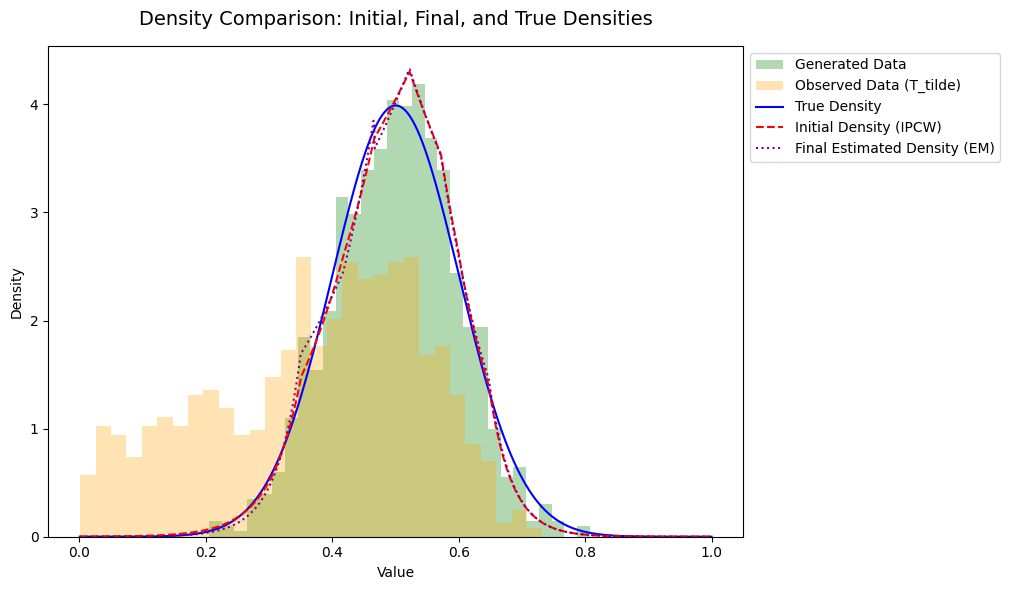

In [ ]:
# Parameters for the true density (truncated normal distribution)
grid_points = initial_results['grid_midpoints']
# Compute the true density
true_density = compute_true_density(grid_points)

# Use placeholders for initial and final results from IPCW and EM algorithms
initial_density = initial_results['estimated_density']
initial_grid_midpoints = initial_results['grid_midpoints']

final_density = final_results['estimated_density']
final_grid_midpoints = final_results['grid_midpoints']

# Event times T and observed times T_tilde from previous data generation
observed_T_tilde = data['T_tilde'].values  # Replace with actual T_tilde

# Increase the figure width to give more room to the plot
plt.figure(figsize=(12, 6))

# Plot the histogram of the generated event times T
plt.hist(T, bins=30, density=True, alpha=0.3, color='green', label="Generated Data")

# Plot the histogram of the observed times T_tilde
plt.hist(observed_T_tilde, bins=30, density=True, alpha=0.3, color='orange', label="Observed Data (T_tilde)")

# Plot the true density
plt.plot(grid_points, true_density, label="True Density", color="blue", linewidth=1.5)

# Plot the initial estimated density from IPCW
plt.plot(initial_grid_midpoints, initial_density, label="Initial Density (IPCW)", color="red", linestyle="--", linewidth=1.5)

# Plot the final estimated density from the EM algorithm
plt.plot(final_grid_midpoints, final_density, label="Final Estimated Density (EM)", color="purple", linestyle=":", linewidth=1.5)

# Add labels, title, and legend with smaller font size
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Density Comparison: Initial, Final, and True Densities", fontsize=14, pad=15)

# Place the legend outside the plot area
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10)

# Adjust the layout to avoid skewing
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()


In [ ]:
score_ipcw = check_score_function(data, initial_results)
print("Score IPCW:", np.linalg.norm(score_ipcw))
score_EM = check_score_function(data, final_results)
print("Score EM:", np.linalg.norm(score_EM))

Score IPCW: 0.0014712344288444663
Score EM: 7.755004485728914e-05


In [ ]:
import numpy as np
from scipy import stats

def summarize_score_vector(score_vector, name="Score"):
    """
    Provides statistical summary of a score vector
    """
    summary = {
        'norm': np.linalg.norm(score_vector),
        'mean': np.mean(score_vector),
        'std': np.std(score_vector),
        'median': np.median(score_vector),
        'min': np.min(score_vector),
        'max': np.max(score_vector),
        'quartiles': np.percentile(score_vector, [25, 50, 75])
    }

    print(f"\n{name} Summary:")
    print(f"Norm: {summary['norm']:.4f}")
    print(f"Mean ± Std: {summary['mean']:.4f} ± {summary['std']:.4f}")
    print(f"Median: {summary['median']:.4f}")
    print(f"Range: [{summary['min']:.4f}, {summary['max']:.4f}]")
    print(f"Quartiles: [{summary['quartiles'][0]:.4f}, {summary['quartiles'][1]:.4f}, {summary['quartiles'][2]:.4f}]")

    return summary

# Usage
summarize_score_vector(score_ipcw, "IPCW Score")
summarize_score_vector(score_EM, "EM Score")


IPCW Score Summary:
Norm: 0.0015
Mean ± Std: 0.0002 ± 0.0002
Median: 0.0002
Range: [0.0000, 0.0010]
Quartiles: [0.0001, 0.0002, 0.0003]

EM Score Summary:
Norm: 0.0001
Mean ± Std: 0.0000 ± 0.0000
Median: 0.0000
Range: [-0.0000, 0.0000]
Quartiles: [0.0000, 0.0000, 0.0000]


{'norm': 7.755004485728914e-05,
 'mean': 1.0917101702994766e-05,
 'std': 1.0588906764112483e-05,
 'median': 1.3813014227341993e-05,
 'min': -5.772410619138468e-06,
 'max': 2.5774879202201678e-05,
 'quartiles': array([2.10422880e-06, 1.38130142e-05, 1.82977257e-05])}

In [ ]:
len(score_ipcw)

26

In [ ]:
len(score_EM)

26

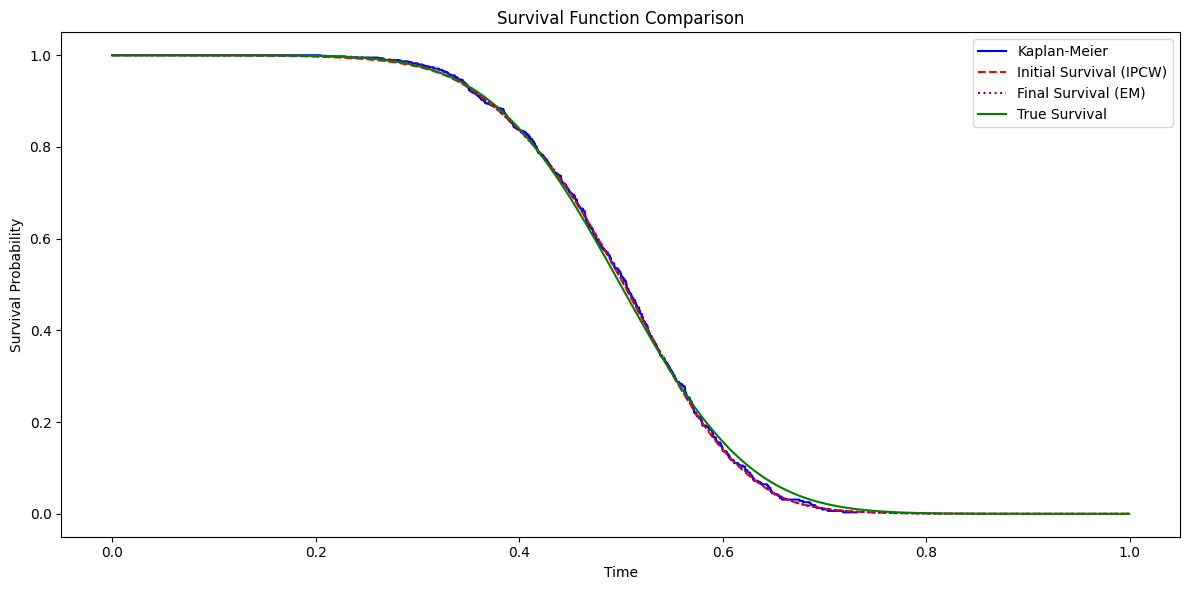

In [ ]:
# Compute the true survival function from the true density
true_cdf = np.cumsum(true_density * np.diff(grid_points, prepend=0))  # Cumulative density
true_survival = 1 - true_cdf  # Survival function

# Extract results from `initial_results` and `final_results`
initial_density = initial_results['estimated_density']
initial_grid_midpoints = initial_results['grid_midpoints']
final_density = final_results['estimated_density']
final_grid_midpoints = final_results['grid_midpoints']

# Compute survival function from estimated densities
def compute_survival_from_density(density, grid_midpoints, delta_j):
    cdf = np.cumsum(density * delta_j)  # Compute the cumulative density
    survival = 1 - cdf  # Compute the survival function
    return survival

# Survival functions from estimated densities
initial_survival = compute_survival_from_density(
    initial_density, initial_grid_midpoints, initial_results['delta_j']
)
final_survival = compute_survival_from_density(
    final_density, final_grid_midpoints, final_results['delta_j']
)

# Kaplan-Meier survival estimation
kmf = KaplanMeierFitter()
kmf.fit(data['T_tilde'], event_observed=data['delta'])

# Plot survival functions
plt.figure(figsize=(12, 6))

# Kaplan-Meier survival
plt.step(
    kmf.survival_function_.index,
    kmf.survival_function_['KM_estimate'],
    label="Kaplan-Meier",
    color="blue",
    where="post",
)

# Initial survival function
plt.plot(
    initial_grid_midpoints,
    initial_survival,
    label="Initial Survival (IPCW)",
    color="red",
    linestyle="--",
)

# Final survival function
plt.plot(
    final_grid_midpoints,
    final_survival,
    label="Final Survival (EM)",
    color="purple",
    linestyle=":",
)

# True survival function
plt.plot(
    grid_points,
    true_survival,
    label="True Survival",
    color="green",
    linestyle="-",
    linewidth=1.5,
)

# Add labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Survival Function Comparison")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
# Define evaluation points
evaluation_points = np.linspace(0.02, 0.98, 10)  # 10 equally spaced points in [0, 1]

# Function to compute survival probabilities at given points from a survival function
def compute_survival_probabilities(survival_function, grid_points, evaluation_points):
    """
    Compute survival probabilities P(T > t) for specified evaluation points.

    Args:
        survival_function (numpy array): The survival function values.
        grid_points (numpy array): The grid points corresponding to the survival function.
        evaluation_points (numpy array): The evaluation points t1, t2, ..., tn.

    Returns:
        numpy array: Survival probabilities P(T > t) at the evaluation points.
    """
    survival_interp = np.interp(evaluation_points, grid_points, survival_function, left=1.0, right=0.0)
    return survival_interp

# Compute survival probabilities from true survival
true_survival_probs = compute_survival_probabilities(true_survival, grid_points, evaluation_points)

# Compute survival probabilities from initial and final estimates
initial_survival_probs = compute_survival_probabilities(initial_survival, initial_grid_midpoints, evaluation_points)
final_survival_probs = compute_survival_probabilities(final_survival, final_grid_midpoints, evaluation_points)

# Compute Kaplan-Meier survival probabilities at evaluation points
# Fit the Kaplan-Meier estimator
kmf.fit(data['T_tilde'], event_observed=data['delta'])

# Predict survival probabilities, handling points beyond observed range
last_time = kmf.survival_function_.index.max()
last_survival = kmf.survival_function_['KM_estimate'].iloc[-1]

# Predict survival probabilities at evaluation points
km_survival_probs = []
for point in evaluation_points:
    if point <= last_time:
        km_survival_probs.append(kmf.predict(point))
    else:
        km_survival_probs.append(last_survival)

# Convert to a NumPy array
km_survival_probs = np.array(km_survival_probs)

# Combine results into a DataFrame for comparison
results = pd.DataFrame({
    "Evaluation Point": evaluation_points,
    "True Survival": true_survival_probs,
    "KM Survival": km_survival_probs,
    "Initial Survival": initial_survival_probs,
    "Final Survival": final_survival_probs,
})

# Display results
print(results)

   Evaluation Point  True Survival  KM Survival  Initial Survival  \
0          0.020000   9.999995e-01     1.000000          0.999976   
1          0.126667   9.999039e-01     1.000000          0.999392   
2          0.233333   9.961123e-01     0.996176          0.993931   
3          0.340000   9.446431e-01     0.947150          0.942785   
4          0.446667   7.013633e-01     0.712168          0.710041   
5          0.553333   2.951727e-01     0.296331          0.293297   
6          0.660000   5.424656e-02     0.030966          0.034326   
7          0.766667   3.773681e-03     0.003167          0.001719   
8          0.873333   9.233820e-05     0.003167          0.000084   
9          0.980000   4.948403e-07     0.003167          0.000002   

   Final Survival  
0        0.999995  
1        0.999803  
2        0.996775  
3        0.948879  
4        0.712009  
5        0.294901  
6        0.034959  
7        0.001666  
8        0.000077  
9        0.000002  


In [ ]:

initial_grid_midpoints = initial_results['grid_midpoints']
true_density = compute_true_density(initial_grid_midpoints)
initial_density = initial_results['estimated_density']
# Compute the KL divergence of the IPCW estimate vs. the true density
kl_divergence_ipcw = calculate_kl_divergence(true_density, initial_density, initial_grid_midpoints)


final_grid_midpoints = final_results['grid_midpoints']
true_density = compute_true_density(final_grid_midpoints)
final_density = final_results['estimated_density']
# Compute the KL divergence of the EM estimate vs. the true density
kl_divergence_em = calculate_kl_divergence(true_density, final_density, final_grid_midpoints)

print("KL Divergence (True vs. IPCW):", kl_divergence_ipcw)
print("KL Divergence (True vs. EM):", kl_divergence_em)


KL Divergence (True vs. IPCW): 0.009384667695076315
KL Divergence (True vs. EM): 0.010340642268173106


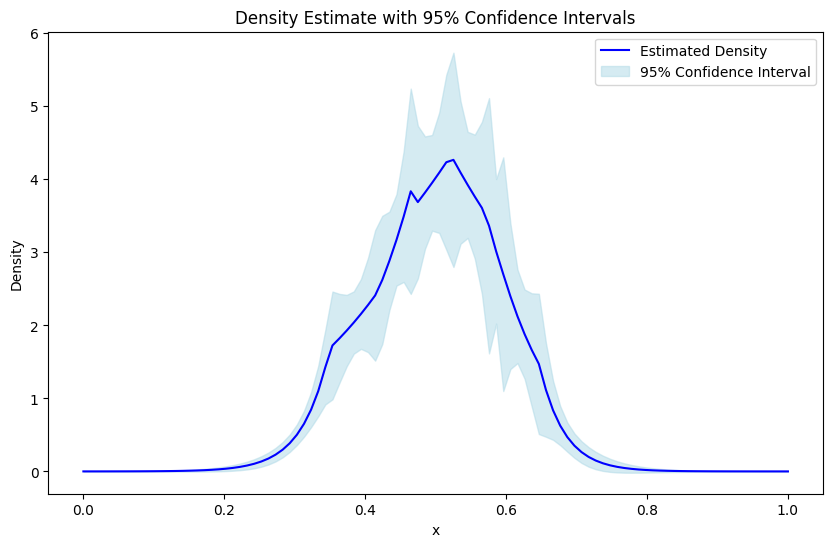

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
import torch

##############################################
# Poinwise confidence intervals
##############################################

##############################################
# 1. Compute individual score contributions
##############################################

def compute_individual_score(row, final_results):
    """
    For a single observation, compute the score contribution (i.e. the derivative of the log-likelihood
    with respect to the non-intercept coefficients) under your model.

    For an uncensored observation (delta==1):
        s_i = φ(T_tilde) - E[φ(X)]
    For a censored observation (delta==0):
        s_i = E[φ(X) | X ≥ T_tilde] - E[φ(X)]

    Parameters:
    -----------
    row : Series
        A row of the data containing at least 'T_tilde' and 'delta'.
    final_results : dict
        Dictionary from the EM algorithm containing at least:
          - "grid_midpoints": 1D array of grid midpoints used for integration.
          - "estimated_density": estimated density on those midpoints.
          - "delta_j": integration weights (grid differences).
          - "grid_points_hal_selected": the knots used for the selected HAL basis.
          - "b_jk": basis functions evaluated on the grid midpoints.
            (Each row corresponds to a grid point and each column to a basis function.)

    Returns:
    --------
    score : 1D numpy array (length = number of selected basis functions)
    """
    T_tilde = row['T_tilde']
    delta = row['delta']
    # Compute the expectation E[φ(X)] on the grid:
    E_phi = np.sum(final_results["b_jk"].T * final_results["estimated_density"] * final_results["delta_j"], axis=1)

    if delta == 1:
        # For an uncensored observation: evaluate the basis at T_tilde.
        df_T = pd.DataFrame({'W1': [T_tilde]})
        phi_T = create_basis_functions(df_T, final_results["grid_points_hal_selected"]).numpy().flatten()
        score = phi_T - E_phi
    else:
        # For a censored observation: compute the conditional expectation E[φ(X) | X ≥ T_tilde].
        grid = final_results["grid_midpoints"]
        mask = grid >= T_tilde
        if np.sum(mask) == 0:
            score = -E_phi
        else:
            num = np.sum(final_results["b_jk"][mask, :].T * final_results["estimated_density"][mask] * final_results["delta_j"][mask], axis=1)
            den = np.sum(final_results["estimated_density"][mask] * final_results["delta_j"][mask])
            cond_exp = num / den
            score = cond_exp - E_phi
    return score

##############################################
# 2. Estimate the covariance matrix of β̂
##############################################

def estimate_covariance_beta(data, final_results):
    """
    Estimate the covariance matrix of the (non-intercept) coefficients β̂.
    We compute the individual score vectors s_i and then estimate the
    Fisher information matrix as the average outer product:

         Î = (1/n) ∑ s_i s_i^T,

    and then use (asymptotically)
         Cov(β̂) ≈ Î⁻¹ / n.

    Parameters:
    -----------
    data : DataFrame
        The original dataset.
    final_results : dict
        The dictionary produced at the end of the EM algorithm.

    Returns:
    --------
    cov_beta : 2D numpy array (p × p), where p = number of selected basis functions.
    """
    scores = []
    for _, row in data.iterrows():
        s = compute_individual_score(row, final_results)
        scores.append(s)
    scores = np.array(scores)  # shape: (n, p)
    n = scores.shape[0]

    # Estimate the expected outer product: Î = (1/n)*∑ s_i s_i^T.
    I_hat = np.dot(scores.T, scores) / n
    try:
        cov_beta = np.linalg.inv(I_hat) / n  # Asymptotic variance
    except np.linalg.LinAlgError:
        cov_beta = np.linalg.pinv(I_hat) / n
    return cov_beta

##############################################
# 3. Estimate the density at an arbitrary x
##############################################

def estimated_density_at(x, final_results):
    """
    For any x ∈ [0,1] (or within the range of interest), return the estimated density.
    Here we use a simple linear interpolation on the grid midpoints stored in final_results.

    Parameters:
    -----------
    x : float or array-like
        The evaluation point(s).
    final_results : dict
        Must contain "grid_midpoints" and "estimated_density".

    Returns:
    --------
    f_x : float or array of estimated density values.
    """
    f_interp = interp1d(final_results["grid_midpoints"], final_results["estimated_density"],
                        kind="linear", bounds_error=False, fill_value="extrapolate")
    return f_interp(x)

##############################################
# 4. Compute the gradient of the density
##############################################

def compute_grad_f(x, final_results):
    """
    Compute the gradient of the estimated density at x with respect to the
    (non-intercept) coefficients. That is, compute

         grad_f(x) = f(x) * [φ(x) - E[φ(X)]],

    where
         f(x) = estimated_density_at(x, final_results),
         φ(x) = the HAL basis function evaluated at x,
         E[φ(X)] = ∑_grid φ(x_grid) f(x_grid) Δx.

    Parameters:
    -----------
    x : float
        The evaluation point.
    final_results : dict
        Must contain:
          - "grid_points_hal_selected": the selected HAL knots.
          - "b_jk": basis functions evaluated on the integration grid.
          - "estimated_density": estimated density on the integration grid.
          - "delta_j": grid differences for integration.

    Returns:
    --------
    grad_f : 1D numpy array, the gradient of f at x with respect to β.
    """
    # Evaluate density at x
    f_x = estimated_density_at(x, final_results)

    # Compute φ(x)
    df_x = pd.DataFrame({'W1': [x]})
    phi_x = create_basis_functions(df_x, final_results["grid_points_hal_selected"]).numpy().flatten()

    # Compute E[φ(X)] using the integration grid:
    E_phi = np.sum(final_results["b_jk"].T * final_results["estimated_density"] * final_results["delta_j"], axis=1)

    grad_f = f_x * (phi_x - E_phi)
    return grad_f

##############################################
# 5. Use the delta method to compute variance
##############################################

def compute_density_variance(x, final_results, cov_beta):
    """
    Compute the approximate variance of the estimated density at x via the delta method.

    Given that
         f(x) = exp(θ₀ + φ(x)^Tβ) / Z,
    its gradient with respect to β is
         grad_f(x) = f(x) * [φ(x) - E[φ(X)]],
    so that
         Var(f(x)) ≈ grad_f(x)^T Cov(β̂) grad_f(x).

    Parameters:
    -----------
    x : float
        The evaluation point.
    final_results : dict
        Must contain the necessary quantities.
    cov_beta : 2D numpy array
        Estimated covariance matrix of β̂.

    Returns:
    --------
    var_f : float, the estimated variance of f(x).
    """
    grad_f = compute_grad_f(x, final_results)
    var_f = np.dot(grad_f, np.dot(cov_beta, grad_f))
    return var_f

##############################################
# 6. Construct confidence intervals for a grid of x's
##############################################

def density_confidence_interval(x_values, final_results, cov_beta, alpha=0.05):
    """
    For each evaluation point in x_values, compute the estimated density,
    its standard error (via the delta method), and the (1-α)% confidence interval.

    Parameters:
    -----------
    x_values : array-like
        Points at which to compute the inference.
    final_results : dict
        The final output from your EM algorithm.
    cov_beta : 2D numpy array
        Estimated covariance matrix of β̂.
    alpha : float
        Significance level (default 0.05 gives 95% confidence intervals).

    Returns:
    --------
    results_df : DataFrame with columns:
         'x'       : evaluation point,
         'density' : estimated density f(x),
         'se'      : standard error,
         'lower'   : lower bound,
         'upper'   : upper bound.
    """
    z = norm.ppf(1 - alpha / 2)
    results = []
    for x in x_values:
        f_x = estimated_density_at(x, final_results)
        var_f = compute_density_variance(x, final_results, cov_beta)
        se = np.sqrt(var_f)
        lower = f_x - z * se
        upper = f_x + z * se
        results.append({'x': x, 'density': f_x, 'se': se, 'lower': lower, 'upper': upper})
    return pd.DataFrame(results)

##############################################
# Example usage after running EM_HAL_algorithm
##############################################

# Suppose you have already run your EM algorithm and obtained final_results:
# final_results, log_likelihoods = EM_HAL_algorithm(...)

# Then, estimate the covariance matrix for the (non-intercept) coefficients:
cov_beta = estimate_covariance_beta(data, final_results)

# Define a set of evaluation points where you want confidence intervals.
x_vals = np.linspace(0, 1, 100)

# Compute the density estimates and their confidence intervals.
ci_df = density_confidence_interval(x_vals, final_results, cov_beta, alpha=0.05)

# Plot the results.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(ci_df['x'], ci_df['density'], label='Estimated Density', color='blue')
plt.fill_between(ci_df['x'], ci_df['lower'], ci_df['upper'], color='lightblue', alpha=0.5,
                 label='95% Confidence Interval')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Density Estimate with 95% Confidence Intervals')
plt.legend()
plt.show()


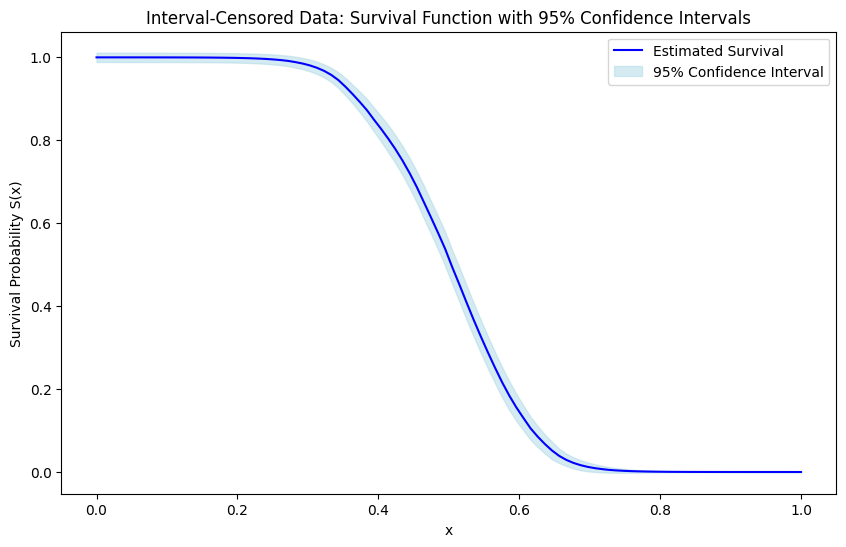

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
import torch
import matplotlib.pyplot as plt

##############################################
# Precompute the Density Gradient on a Fine Uniform Grid
##############################################

def precompute_grad_f_grid(final_results, grid_size=1000):
    """
    Precompute the gradient of the estimated density f(x) on a uniform grid over [0,1].

    Parameters:
      final_results : dict, the HAL estimation result (contains keys used in compute_grad_f)
      grid_size : int, number of points in the uniform grid (default: 1000)

    Returns:
      grid : numpy array of shape (grid_size,), the uniform grid points over [0,1]
      grad_f_grid : numpy array of shape (grid_size, p), where p is the number of non-intercept coefficients,
                    containing grad_f(x) at each grid point.
      delta : float, the uniform grid spacing.
    """
    grid = np.linspace(0, 1, grid_size)
    grad_f_list = []
    for x in grid:
        grad_f_list.append(compute_grad_f(x, final_results))
    grad_f_grid = np.array(grad_f_list)  # shape: (grid_size, p)
    delta = grid[1] - grid[0]
    return grid, grad_f_grid, delta

##############################################
# Compute the Survival Gradient Using the Precomputed Grid
##############################################

def compute_grad_S_from_precomputed(x0, grid, grad_f_grid, delta):
    """
    Given a precomputed uniform grid and corresponding grad_f values,
    compute the survival gradient:
         ∇_β S(x0) = ∫_{x0}^1 ∇_β f(y) dy,
    by summing the precomputed gradients for grid points >= x0.

    Parameters:
      x0 : float, evaluation point.
      grid : numpy array, the precomputed uniform grid over [0,1].
      grad_f_grid : numpy array, precomputed gradient values at each grid point.
      delta : float, uniform grid spacing.

    Returns:
      grad_S : 1D numpy array, the approximate gradient vector of S(x0).
    """
    mask = grid >= x0
    grad_S = np.sum(grad_f_grid[mask], axis=0) * delta
    return grad_S

##############################################
# Survival Function and Variance via Delta Method
##############################################

def estimated_survival_at(x0, final_results):
    """
    Estimate the survival function S(x0) = ∫_{x0}^1 f(y) dy using a Riemann sum
    on the original integration grid.
    """
    grid = final_results["grid_midpoints"]
    f = final_results["estimated_density"]
    delta = final_results["delta_j"]
    mask = grid >= x0
    return np.sum(f[mask] * delta[mask])

def compute_survival_variance_precomputed(x0, final_results, cov_beta, grid, grad_f_grid, delta):
    """
    Compute the approximate variance of the survival function S(x0) using the precomputed
    survival gradient and the delta method.

    Var(S(x0)) ≈ (∇_β S(x0))ᵀ · Cov(β) · (∇_β S(x0))
    """
    grad_S = compute_grad_S_from_precomputed(x0, grid, grad_f_grid, delta)
    return np.dot(grad_S, np.dot(cov_beta, grad_S))

def survival_confidence_interval_precomputed(x_values, final_results, cov_beta, grid, grad_f_grid, delta, alpha=0.05):
    """
    For each evaluation point x0 in x_values, compute the survival function S(x0)
    and its (1-α)% confidence interval using the delta method with precomputed gradients.
    """
    z = norm.ppf(1 - alpha/2)
    results = []
    for x0 in x_values:
        S_x0 = estimated_survival_at(x0, final_results)
        var_S = compute_survival_variance_precomputed(x0, final_results, cov_beta, grid, grad_f_grid, delta)
        se = np.sqrt(np.maximum(var_S, 0))
        lower = S_x0 - z * se
        upper = S_x0 + z * se
        results.append({'x': x0, 'survival': S_x0, 'se': se, 'lower': lower, 'upper': upper})
    return pd.DataFrame(results)

##############################################
# Example Usage
##############################################

# Assume you have already obtained your HAL estimation results in a dictionary "final_results"
# (which contains keys: "estimated_density", "grid_midpoints", "delta_j",
# "grid_points_hal_selected", "b_jk", etc.), and you have computed the covariance matrix
# for the non-intercept coefficients as cov_beta_interval (for instance, using a function like
# estimate_covariance_beta_interval with ridge regularization).

# Precompute the common fine grid for density gradients:
grid, grad_f_grid, delta = precompute_grad_f_grid(final_results, grid_size=1000)

# Define evaluation points for the survival function (for example, 100 points in [0,1]):
x_vals = np.linspace(0, 1, 100)

# Compute the survival confidence intervals using the precomputed gradient grid:
surv_ci_df = survival_confidence_interval_precomputed(x_vals, final_results, cov_beta, grid, grad_f_grid, delta, alpha=0.05)

# Plot the survival function with 95% confidence intervals:
plt.figure(figsize=(10, 6))
plt.plot(surv_ci_df['x'], surv_ci_df['survival'], label='Estimated Survival', color='blue')
plt.fill_between(surv_ci_df['x'], surv_ci_df['lower'], surv_ci_df['upper'],
                 color='lightblue', alpha=0.5, label='95% Confidence Interval')
plt.xlabel('x')
plt.ylabel('Survival Probability S(x)')
plt.title('Interval-Censored Data: Survival Function with 95% Confidence Intervals')
plt.legend()
plt.show()
